In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from typing import Optional, Tuple

import time

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [2]:
from datetime import datetime
def showTime():
    return str("["+datetime.now().strftime('%Y-%m-%d %H:%M:%S.%f')+" UTC]")

In [3]:
class Head(nn.Module):
    """A single self-attention head for a Transformer model with causal masking.

    This module processes input embeddings into query, key, and value vectors,
    computes scaled dot-product attention scores with causal masking to prevent 
    future context leakage, and outputs weighted value vectors.

    Attributes:
        key (nn.Linear): Projects input embeddings to key vectors of shape (head_size).
        query (nn.Linear): Projects input embeddings to query vectors of shape (head_size).
        value (nn.Linear): Projects input embeddings to value vectors of shape (head_size).
        tril (Tensor): Lower triangular mask buffer enforced during attention computation.
        dropout (nn.Dropout): Dropout layer applied post-softmax for regularization.
    """

    def __init__(self, n_embd: int, head_size: int, block_size: int, dropout: float) -> None:
        """Initialize the self-attention head.
        
        Args:
            n_embd (int): Input embedding dimension (must match input's last dimension).
            head_size (int): Dimensionality of key/query/value vectors (output size).
            block_size (int): Maximum sequence length for the causal mask buffer.
            dropout (float): Dropout probability for attention weights (0-1 range).
        """
        super().__init__()

        # [KEY, QUERY, VALUE LINEAR PROJECTIONS]
        # Linear layers project embeddings to lower-dimensional key/query/value spaces 
        # without bias terms (common in some Transformer architectures for simplicity)
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        # [CAUSAL MASK CREATION]
        # Creates a fixed triangular mask for enforcing sequential order dependencies
        # Lower triangular part (1s below and on the main diagonal) allows attention 
        # to current and previous positions only. Stored as a buffer, not a learnable parameter
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        # [DROPOUT LAYER]
        # Reduces overfitting by randomly zeroing attention probabilities during training
        self.dropout = nn.Dropout(dropout)


    # x Tensor shape (batch_size, time_steps, embedding_dim)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Perform self-attention computation on input tensor.
        
        Args:
            x (Tensor): Input embeddings tensor
            
        Returns:
            Tensor: Output attention vectors of shape (B, T, head_size)
        """
        # --- DIMENSION UNPACKING ---
        # B=batch_size, T=sequence_length, C=embedding_dim
        B,T,C = x.shape

        # --- LINEAR PROJECTIONS ---
        # Project embeddings into query, key, and value spaces (all T x head_size matrices)
        k = self.key(x)    # (B, T, head_size) - projected key vectors
        q = self.query(x)  # (B, T, head_size) - projected query vectors


        # --- ATTENTION SCORE COMPUTATION ---
        # 1. Compute query-key dot product for all pairs (scaled to prevent softmax saturation)
        wei = q @ k.transpose(-2,-1) # (B, T, head_size) @ (B, head_size, T) => (B, T, T)
        scale_factor = (k.shape[-1])**-0.5 # sqrt(head_size) for stability
        wei_scaled = wei / scale_factor     # Scaling prevents extreme values

        # 2. Apply causal mask to enforce sequential order
        # Masking ensures position i can't attend to j > i (future tokens)
        # Crop mask to current sequence length T
        wei_scaled = wei_scaled.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # mark upper triangle (forbidden)

        # 3. Softmax normalization to get probabilities
        # Large negative values (-inf) become zero after softmax
        att_weights = F.softmax(wei_scaled, dim=-1)  # (B, T, T)

        # 4. Apply dropout to attention probabilities
        # Dropout randomly nullifies connections for regularization
        att_weights_dropped = self.dropout(att_weights)
        
        # --- VALUE COMBINING ---
        # Project input to value vectors then combine using attention weights
        v = self.value(x)         # (B, T, head_size) - projected value vectors
        # Matrix multiplication (B, T, T) x (B, T, head_size) = (B, T, head_size)
        out = att_weights_dropped @ v  

        return out


class MultiHeadAttention(nn.Module):
    """MultiHeadAttention implements parallel self-attention for multiple heads to process inputs independently.

    This module combines the outputs of multiple attention heads (via concatenation) and applies 
    a linear projection to restore the original embedding dimensionality. It is designed for 
    sequential/casual attention (e.g., in language modeling) where each position attends only to previous tokens.

    Parameters:
        n_embd (int): Input embedding dimension (must match the last dimension of the input tensor).
        num_heads (int): Number of parallel self-attention heads.
        head_size (int): Dimensionality of key, query, and value vectors for each head.
        block_size (int): Maximum context length for positional masking (shared with all heads). 
        dropout (float): Dropout probability applied to attention weights (head levels) and output (post-projection).

    Attributes:
        heads (nn.ModuleList): List of self-attention heads responsible for parallel computations.
        proj (nn.Linear): Projects the concatenated head outputs back to the original embedding dimension.
        dropout (nn.Dropout): Regularization layer applied after the projection.
    """

    def __init__(self, n_embd: int, num_heads: int, head_size: int, block_size: int, dropout: float) -> None:
        """Initialize the multi-head attention module with parallel heads and projection layer.
        
        Args:
            n_embd (int): Input embedding dimension (input's last dimension).
            num_heads (int): Number of parallel attention heads.
            head_size (int): Dimension of each head's key/query/value vectors.
            block_size (int): Max context length for causal masking (used by each head).
            dropout (float): Dropout rate for attention weights and output (0-1 range).
        """
        super().__init__()
        # 1. Create parallel heads
        # Each head is initialized with identical parameters and structure
        self.heads = nn.ModuleList([Head(n_embd, head_size, block_size, dropout) for _ in range(num_heads)])

        # 2. Concatenation projection layer
        # Combines outputs from all heads into original embedding dimension
        # Total input dimension = head_size * num_heads (sum of all heads' outputs)
        # Output dimension = n_embd
        self.proj = nn.Linear(head_size * num_heads, n_embd)

        # 3. Dropout for regularization after projection
        self.dropout = nn.Dropout(dropout)
        
    # x input with shape (batch_size, seq_length, embedding_dim)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Process input through parallel heads and project output.
        
        Args:
            x (Tensor): Input embeddings tensor
            
        Returns:
            Tensor: Processed embeddings tensor (batch_size, seq_length, embedding_dim)
        """
        # Step 1: Compute attention outputs for each head in parallel
        # - Each head processes input tensor independently → outputs (B, T, head_size)
        # - Cropping example: For 3 heads → list [head1_output, head2_output, head3_output]
        # - Final concatenated shape before projection: (B, T, head_size * num_heads)
        outputs = [h(x) for h in self.heads]  # type: list[Tensor]
        concatenated = torch.cat(outputs, dim=-1)  # (B,T,F) -> (B,T,[h1,h1,h1,h1,h2,h2,h2,h2,h3,h3,h3,h3])
        # Shape after concatenation: (batch_size, T, head_size*num_heads)

        # TODO: check if needed, remove if not
        # Step 2: Linear projection to restore original embedding dimension
        projected = self.proj(concatenated) # Output shape: (batch_size, T, n_embd)

        # Step 3: Apply dropout regularization to final output
        output = self.dropout(projected)
        
        return output


class FeedForward(nn.Module):
    """A feed-forward neural network layer with bottleneck architecture for Transformer.

    This module performs a linear transformation followed by a non-linear activation, 
    then another linear projection back to the original dimension with optional dropout.

    Args:
        n_embd (int): Input and output embedding dimension (the blocks are designed to be residual).
        dropout (float): Dropout rate for regularization. 

    Attributes:
        net (nn.Sequential): A neural network sequence comprising:
            1. A linear layer expanding to 4x input dimension.
            2. ReLU activation for non-linearity.
            3. A linear layer projecting back to original dimension.
            4. Dropout for regularization.
    """
    def __init__(self, n_embd: int, dropout: float) -> None:
        super().__init__()
        # Feeds through a ReLU-activated bottleneck layer with 4x expansion
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),      # Expand input to 4x width
            nn.ReLU(),                          # Non-linear activation
            nn.Linear(4 * n_embd, n_embd),      # Back to input dimension
            nn.Dropout(dropout)                 # Regularization 
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass applying the feed-forward sequence.

        Args:
            x (Tensor): Input tensor of shape (batch_size, sequence_length, n_embd)
            
        Returns:
            Tensor: Output tensor with residual connection applied (same shape as input).
        """
        return self.net(x) # Directly applies the sequential network layers

    
class Block(nn.Module):
    """Transformer block combining self-attention and feed-forward layers with residual connections.

    Implements the core Transformer architecture with post-norm (normalization applied after residual connections). 

    Args:
        n_embd (int): Dimension of input embeddings.
        n_head (int): Number of self-attention heads.
        block_size (int): Maximum context length (required for causal masking).
        dropout (float): Dropout rate for attention and feed-forward layers.

    Attributes:
        sa (MultiHeadAttention): Multi-head self-attention layer with causal masking.
        ffwd (FeedForward): Feed-forward neural network subnet.
        ln1 (nn.LayerNorm): First layer normalization to stabilize training.
        ln2 (nn.LayerNorm): Second layer normalization after feed-forward layer.
    """
    
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float) -> None:
        super().__init__()
        head_size = n_embd // n_head
        error_message = f"n_embd {n_embd} must be divisible by n_head {n_head}"
        assert head_size * n_head == n_embd, error_message

        self.sa = MultiHeadAttention(    # Initialize causal self-attention layer
            n_embd=n_embd,
            num_heads=n_head,
            head_size=head_size,
            block_size=block_size,
            dropout=dropout
        )
        self.ffwd = FeedForward(n_embd=n_embd, dropout=dropout)  # Feed-forward subnet
        self.ln1 = nn.LayerNorm(n_embd)         # Normalization after attention
        self.ln2 = nn.LayerNorm(n_embd)         # Normalization after feed-forward
  
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Execute Transformer block computation with post-norm architecture.

        Args:
            x (Tensor): Input tensor of shape [batch_size, sequence_length, n_embd]

        Steps:
            1. Self-Attention: Compute attention with residual and LayerNorm.
            2. Feed-Forward: Apply non-linear processing with residual and LayerNorm.
            
        Returns:
            Tensor: Transformer-block processed tensor (same shape as input).
        """
        # 1. Self-Attention sublayer
        y = self.sa(x)          # Compute multi-head attention
        x = self.ln1(x + y)     # Add residual connection + normalize

        # 2. Feed-Forward sublayer
        y = self.ffwd(x)        # Non-linear bottleneck
        x = self.ln2(x + y)     # Residual + normalization

        return x


class GPTLanguageModel(nn.Module):
    """A full autoregressive language model with multi-head self-attention and positional embeddings.
    
    This model combines token and positional embeddings with a sequence of self-attention blocks to predict the next token in a sequence.
    
    Attributes:
        vocab_size (int): Size of the token vocabulary.
        n_embd (int): Dimensionality of token and positional embeddings.
        n_head (int): Number of self-attention heads.
        block_size (int): Maximum context length the model can handle.
        n_layer (int): Number of transformer blocks in the network.
        device (str): Device for tensor operations ('cpu' or 'cuda').
        token_embedding_table (nn.Embedding): Maps tokens to embedding vectors.
        position_embedding_table (nn.Embedding): Encodes positional information up to block_size positions.
        blocks (nn.Sequential): Sequence of transformer blocks processing embeddings.
        ln_f (nn.LayerNorm): Final layer normalization after transformer blocks.
        lm_head (nn.Linear): Linear layer predicting next-token probabilities.
    """
    def __init__(
        self,
        vocab_size: int,
        n_embd: int,
        n_head: int,
        block_size: int,
        n_layer: int,
        dropout: float,
        device: str,
        ignore_index: int = -100
    ) -> None:
        """Initialize the GPT-style language model.
        
        Args:
            vocab_size (int): Number of unique tokens in the vocabulary.
            n_embd (int): Dimension of token and positional embeddings (output size of embeddings).
            n_head (int): Number of parallel attention heads.
            block_size (int): Maximum sequence length the model can process.
            n_layer (int): Number of transformer blocks in the neural network.
            dropout (float): Dropout probability applied in attention and feedforward layers.
            device (str): Execution device ('cuda' for GPU acceleration).
            ignore_index (int): Label value to ignore in loss calculation (default: -100).
        """
        super().__init__()
        self.ignore_index = ignore_index
        self.block_size = block_size
        self.device = device

        # Embedding layers map input indices to dense vectors
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        # how many indices of size n_enbd
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        # Sequential transformer blocks
        # how many decoder blocks running sequentially
        self.blocks = nn.Sequential(*[
            Block(n_embd, n_head, block_size, dropout) 
            for _ in range(n_layer)
        ])

        # Final processing layers
        self.ln_f = nn.LayerNorm(n_embd) # Final layer normalization stabilizes training
        self.lm_head = nn.Linear(n_embd, vocab_size) # Predict next token probabilities

        # Initialize weights using standard transformer initialization strategy
        self.apply(self._init_weights)
        self.to(device) # Move all components to the specified device

    def _init_weights(self, module: nn.Module) -> None:
        """Initialize weights using heuristics from the original Transformer paper.
        
        Args:
            module (nn.Module): Module to be initialized (linear/embedding layers).
        """
        if isinstance(module, nn.Linear):
            # Weight initialization tailored for deep networks (Gaussian with σ=0.02)
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                # Bias terms initialized to zero as per best practices
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            # Embedding weights initialized with small random values
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    
    def forward(self, input_tokens: torch.Tensor, targets: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """Compute logit predictions and optionally calculate loss.
        
        Args:
            input_tokens (Tensor): Input tensor of shape (batch_size, context_length)
            targets (Tensor, optional): Target tokens of shape (batch_size, context_length)
        
        Returns:
            logits (Tensor): Unnormalized token probabilities (batch_size, context_length, vocab_size)
            loss (Tensor, optional): Loss value for training if targets provided
        """
        # Batch size and current sequence length
        B,T = input_tokens.shape

        # 1. Token embeddings (B, T) → (B, T, C)
        # index and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(input_tokens) # (B,T,C)

        # 2. Positional embeddings (T) → (T, C)
        # Create a range tensor up to current T (dynamic slicing for varying input lengths)
        tok_positions = torch.arange(T, device=self.device)
        pos_emb = self.position_embedding_table(tok_positions) # (T,C)

        # 3. Combine embeddings with element-wise addition → (B, T, C)
        x = tok_emb + pos_emb # (B,T,C)

        # 4. Pass through transformer blocks → (B, T, C)
        x = self.blocks(x) # (B,T,C)

        # 5. Final layer normalization → (B, T, C)
        x = self.ln_f(x) # (B,T,C)

        # 6. Compute next-token predictions → (B, T, vocab_size)
        logits = self.lm_head(x) # (B,T,vocab_size)

        # Loss calculation (only done during training)
        if targets is None:
            loss = None
        else:
            # Reshape to merge batch and time dimensions for cross-entropy (B*T, vocab_size)
            B,T,C = logits.shape
            logits_flat = logits.view(B*T, C)
            targets_flat  = targets.view(B*T)

            # Calculate cross-entropy loss ignoring padding tokens
            loss = F.cross_entropy(logits_flat, targets_flat , ignore_index=self.ignore_index)
            
        return logits, loss
   
    def generate(self, input_tokens: torch.Tensor, max_new_tokens: int) -> torch.Tensor:
        """Generate new tokens autoregressively using greedy sampling.
        
        Args:
            input_tokens (Tensor): Starting token sequence (B, T_0)
            max_new_tokens (int): Number of tokens to generate
        
        Returns:
            Tensor: Extended sequence including generated tokens (B, T_0 + max_new_tokens)
        """
        # index is (B,T) array of idices in the current context
        for _ in range(max_new_tokens):

            # Crop input to model's maximum context length
            cropped_input = input_tokens[:, -self.block_size:]

            # Get full logits and ignore loss (targets not provided)
            logits, _ = self(cropped_input)

            # Get next token predictions from last time-step's output
            # Shape narrowing (B, T, C) → (B, 1, C)
            logits = logits[:, -1, :] # becomes (B,C)

            # Convert logits to probabilities (axis=-1 ensures proper normalization)
            probs = F.softmax(logits, dim=-1) # (B,C)

            # Sample one token index from distribution
            next_token = torch.multinomial(probs, num_samples=1) # (B,1)

            # Extend the sequence with new prediction
            input_tokens = torch.cat((input_tokens, next_token), dim=1) # (B,T+1)

        return input_tokens
    
    def advanced_generation(self,
        input_tokens: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
        top_p: Optional[float] = None
    ) -> torch.Tensor:
        """Generate tokens with advanced sampling strategies (temperature, nucleus, top-k).
        
        Args:
            input_tokens (Tensor): Initial tokens of shape (B, T)
            max_new_tokens (int): Maximum tokens to generate
            temperature (float): Controls randomness (1=default, 0→deterministic)
            top_k (int, optional): Keep only top K most probable tokens (None→disabled)
            top_p (float, optional): Keep smallest window ≥ cumulative prob mass p (None→disabled)
        
        Returns:
            Tensor: Generated sequence (B, T + max_new_tokens)
        """
        
        for _ in range(max_new_tokens):
            # Context window clipping
            cropped_input = input_tokens[:, -self.block_size:]

            # Get predictions without loss calculation
            logits, _ = self(cropped_input)

            # Only consider last predicted token
            next_logits = logits[:, -1, :] 

            # Temperature scaling controls exploration-exploitation tradeoff
            scaled_logits = next_logits / temperature

            # Apply top-k sampling (if requested)
            if top_k is not None:
                # Find top-k values and set others to -inf
                top_k_values, _ = torch.topk(scaled_logits, min(top_k, scaled_logits.size(-1)))
                mask = scaled_logits < top_k_values[:, [-1]]  # Broadcast comparison
                scaled_logits[mask] = -float("inf")

            # Convert to probabilities after any pre-processing
            probs = F.softmax(scaled_logits, dim=-1)

            # Apply nucleus (top-p) sampling (if requested)
            if top_p is not None:
                sorted_probs, sorted_indices = torch.sort(probs, descending=True)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                # Determine indices to mask by identifying positions exceeding p
                sorted_indices_to_remove = cumulative_probs > top_p

                # Shift mask to apply to the appropriate tokens (keeps min. prob mass p)
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0
                indices_to_remove = torch.zeros_like(logits).scatter_(1, sorted_indices, sorted_indices_to_remove)

                # Set probabilities of removed tokens to zero and normalize
                probs[indices_to_remove] = 0.0
                probs = probs / probs.sum(dim=-1, keepdim=True)

            # Sample with controlled probability distribution
            next_token = torch.multinomial(probs, num_samples=1)

            # Extend sequence
            input_tokens = torch.cat((input_tokens, next_token), dim=1)

        return input_tokens  # Final expanded tensor

In [4]:
# Example usage test
vocab_size_test = 16394
embedding_size_test = 512
number_of_heads_test = 8
block_size_test = 1024
number_of_blocks_test = 1
dropout_test = 0.2
head_size_test = embedding_size_test // number_of_heads_test
device_test = 'cuda' if torch.cuda.is_available() else 'cpu'


model = GPTLanguageModel(
    vocab_size=vocab_size_test,
    n_embd=embedding_size_test,
    n_head=number_of_heads_test,
    block_size=block_size_test,
    n_layer=number_of_blocks_test,
    dropout=dropout_test,
    device=device_test
)

model_size = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model size: {model_size / 1e6:.2f}M parameters")

print(
    f"Model created with {embedding_size_test=}, {number_of_heads_test=}, head_size={embedding_size_test//number_of_heads_test}")

# Create dummy input
input_tokens = torch.randint(0, vocab_size_test, (2, 50), device=device_test)

# Test forward pass
# Use input as target for testing shape
logits, loss = model(input_tokens, targets=input_tokens)
if loss is not None:
    print("Loss:", loss.item())

# Test generation
print("Generating...")
# Start generation from first 10 tokens
generated_tokens = model.generate(input_tokens[:, :10], max_new_tokens=20)
print("Generated tokens shape:", generated_tokens.shape)
print("Generated sequence example (first batch):\n",
        generated_tokens[0].tolist())

# Test advanced generation
print("\nAdvanced Generating (top_k=5, temp=0.8)...")
generated_tokens_adv = model.advanced_generation(
    input_tokens[:, :10],
    max_new_tokens=20,
    temperature=0.8,
    top_k=10
)
print("Generated tokens shape (adv):", generated_tokens_adv.shape)
print("Generated sequence example (adv, first batch):\n",
        generated_tokens_adv[0].tolist())

Model size: 20.48M parameters
Model created with embedding_size_test=512, number_of_heads_test=8, head_size=64
Loss: 9.835199356079102
Generating...
Generated tokens shape: torch.Size([2, 30])
Generated sequence example (first batch):
 [11112, 2479, 1284, 3986, 9200, 2564, 11891, 15786, 7821, 14966, 10612, 5084, 13403, 4069, 9816, 13206, 11410, 10834, 6387, 5614, 10782, 9138, 2740, 4610, 11527, 12476, 11749, 12324, 7033, 11282]

Advanced Generating (top_k=5, temp=0.8)...
Generated tokens shape (adv): torch.Size([2, 30])
Generated sequence example (adv, first batch):
 [11112, 2479, 1284, 3986, 9200, 2564, 11891, 15786, 7821, 14966, 861, 16253, 15159, 10289, 1657, 1736, 4941, 2852, 3407, 4496, 13190, 14377, 3116, 12697, 3605, 13475, 7979, 5419, 7365, 5501]


GPT2 Training Sliding Window 50% Overlap

In [5]:
import os
import time
import logging
from typing import Tuple, Dict, List

import numpy as np
import torch
from tqdm import tqdm
from minbpe import RegexTokenizer

In [6]:
## -- Utility Functions ---------------------------------------------------
# -- Getting Size of Vocab Function ------------------------------------------
def get_vocab_size(tokenizer: RegexTokenizer) -> int:
    """
    Return the total vocabulary size of the tokenizer, including any special tokens.

    Args:
        tokenizer: An instance of RegexTokenizer with 'vocab' and 'special_tokens' attributes.

    Returns:
        Total number of tokens (vocabulary size + special tokens).
    """
    return len(tokenizer.vocab) + len(tokenizer.special_tokens)


# -- Batch Extraction Function ------------------------------------------
def get_batch_for_training(
    batch_idx: int,
    data: np.ndarray,
    window_starts: List[int],
    block_size: int,
    batch_size: int,
    device: torch.device
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Extract a batch of overlapping sequences for model training.

    Args:
        batch_idx: Index of the batch to retrieve.
        data: NumPy array or memmap of token IDs.
        window_starts: List of start indices for sliding windows.
        block_size: Number of tokens per input sequence.
        batch_size: Number of sequences per batch.
        device: Torch device (cpu or cuda).

    Returns:
        x_batch: Tensor of shape (batch_size, block_size).
        y_batch: Tensor of shape (batch_size, block_size), one-step-shifted targets.
    """
    # Determine which window starts belong to this batch
    starts = window_starts[batch_idx * batch_size : (batch_idx + 1) * batch_size]
    # Gather input and target sequences
    x_np = np.stack([data[s : s + block_size] for s in starts])
    y_np = np.stack([data[s + 1 : s + block_size + 1] for s in starts])
    # Convert to Torch tensors on the target device
    x_batch = torch.tensor(x_np, dtype=torch.long, device=device)
    y_batch = torch.tensor(y_np, dtype=torch.long, device=device)
    return x_batch, y_batch


# --- Sample a random batch for loss estimation --------------------------------
def get_batch_for_loss_estimation(
    split: str,
    data: np.ndarray,
    split_index: int,
    block_size: int,
    batch_size: int,
    device: torch.device
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Sample one random batch for loss estimation from train or validation split.

    Args:
        split: 'train' or 'val'.
        data: Full token array (NumPy or memmap).
        split_index: Index separating train/validation data.
        block_size: Context window length.
        batch_size: Number of sequences per batch.
        device: Torch device.

    Returns:
        x_batch, y_batch: Torch tensors of shape (batch_size, block_size).
    """
    # Define slice boundaries based on split
    if split == 'train':
        start_i, end_i = 0, split_index
    else:
        start_i, end_i = split_index, len(data)
    # Compute how many full blocks are available
    num_blocks = (end_i - start_i - 1) // block_size
    # Randomly sample block indices
    idxs = torch.randint(0, num_blocks, (batch_size,), device=device)

    x_list, y_list = [], []
    # Build sequences for each sampled index
    for idx in idxs:
        off = start_i + idx.item() * block_size
        x_list.append(data[off : off + block_size])
        y_list.append(data[off + 1 : off + block_size + 1])
    # Stack and convert to tensors
    x_np = np.stack(x_list)
    y_np = np.stack(y_list)
    x_batch = torch.tensor(x_np, dtype=torch.long, device=device)
    y_batch = torch.tensor(y_np, dtype=torch.long, device=device)
    return x_batch, y_batch


# -- Estimate Loss -------------------------------------------------
@torch.no_grad()
def estimate_loss(
    model,
    data: np.ndarray,
    split_index: int,
    block_size: int,
    batch_size: int,
    device: str,
    eval_iters: int = 50
) -> Dict[str, float]:
    """
    Compute average loss on `eval_iters` random batches from both train/val splits.

    Args:
        model:       GPTLanguageModel in eval mode
        data:        full token array
        split_index: boundary index between train/val
        block_size:  context window length
        batch_size:  number of windows per batch
        device:      torch device
        eval_iters:  how many batches to sample per split

    Returns:
        dict with keys 'train' and 'val' mapping to average loss
    """
    losses = {}
    model.eval()

    for split in ('train', 'val'):
        total = 0.0
        for _ in range(eval_iters):
            X, Y = get_batch_for_loss_estimation(
                split, data, split_index, block_size, batch_size, device
            )
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                _, loss = model(X, Y)
            total += loss.item()
        losses[split] = total / eval_iters

    model.train()
    return losses


# -- Checkpoint Saving -------------------------------------------------
def save_checkpoint(
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    file_path: str
) -> None:
    """
    Save model and optimizer state to disk for later resumption.

    Args:
        model: Trained GPTLanguageModel.
        optimizer: Associated optimizer (e.g., AdamW).
        epoch: Current epoch or step number.
        loss: Latest loss value.
        file_path: File path for checkpoint.
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    torch.save(checkpoint, file_path)

In [7]:
# -- Logging Configuration ----------------------------------------------
run_id = int(time.time())

logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S", 
    encoding='utf-8'
)
logger = logging.getLogger(__name__)

# Ensure logs directory exists
LOG_DIR = os.path.join("logs")
if not os.path.exists(LOG_DIR):
    os.makedirs(LOG_DIR)

# Create file handler
log_file = os.path.join(LOG_DIR, f"train_{run_id}.log")
file_handler = logging.FileHandler(log_file, mode='w', encoding='utf-8')
file_handler.setLevel(logging.DEBUG)

# Optional: use same format as console
formatter = logging.Formatter("%(asctime)s [%(levelname)s] %(message)s", "%H:%M:%S")
file_handler.setFormatter(formatter)

# Add handler to logger
logger.addHandler(file_handler)

logger.info(f"Logging to file: {log_file}")

# -- Load Tokenizer -----------------------------------------------------
TOKENIZER_DIR = os.path.join("output_v7", "tokenizer")
TOKENIZER_MODEL = os.path.join(TOKENIZER_DIR, "en_tokenizer.model")
tokenizer = RegexTokenizer()
tokenizer.load(model_file=TOKENIZER_MODEL)
vocab_size = get_vocab_size(tokenizer)
logger.info(f"Vocab size: {vocab_size}")

# -- Model Configuration ------------------------------------------------
torch.manual_seed(1337)
block_size = 1024
n_embd = 384
n_head = 12
n_layer = 8
dropout = 0.2
batch_size = 8

device = 'cuda' if torch.cuda.is_available() else 'cpu'
logger.info(f"Using device: {device}")

# create an instance of GPTLanguageModel class
model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device
).to(device)
logger.info(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

# -- Load Data ----------------------------------------------------------
# Load as a memory mapped file object by using mmap_mode='r' to save RAM
data = np.load(
    os.path.join('output_v7', 'encoded_data','encoded_output_v7_accuracy.npy'),
    mmap_mode='r'
)
logger.info(f"Data shape: {data.shape}")

# -- Train/Val Split -----------------------------------------------------
# allocating 90% for training and 10% for validation
split_index = int(0.9 * len(data))

# -- Prepare 50% Overlapping Windows -----------------------------------
stride = block_size // 2
max_start = split_index - block_size - 1
window_starts = list(range(0, max_start + 1, stride))
num_windows = len(window_starts)
total_batches = num_windows // batch_size
logger.info(f"Total overlapping windows: {num_windows}, total_batches: {total_batches}")

# -- Optimizer & Training Setup -----------------------------------------
learning_rate = 3e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
grads_accum_steps = 8
eval_interval = 1000
save_interval = 5000
num_epochs = 5  # configurable number of epochs
val_loss_threshold = 3.0  # stop if val loss exceeds 3x train loss


17:34:07 [INFO] Logging to file: logs\train_1746545647.log
17:34:07 [INFO] Vocab size: 16394
17:34:07 [INFO] Using device: cuda
17:34:07 [INFO] Model parameters: 27.19M
17:34:07 [INFO] Data shape: (199979844,)
17:34:07 [INFO] Total overlapping windows: 351526, total_batches: 43940


In [8]:
# -- Tracking metrics ------------------------------------------------------
batches_processed = 0
train_losses, val_losses, batch_nums = [], [], []
early_stop = False
t0 = time.time()

pre_training_dir = os.path.join('output_v8', 'pre_training', f'run_{run_id}')
if not os.path.exists(pre_training_dir):
    os.makedirs(pre_training_dir)
    logger.info(f"Created: {pre_training_dir}")


# -- Training Loop ------------------------------------------------------
torch.set_float32_matmul_precision('high')
for epoch in range(num_epochs):
    if early_stop == False:
        logger.info(f"Starting epoch {epoch + 1}/{num_epochs}")
        optimizer.zero_grad(set_to_none=True)
        t0 = time.time()


        for batch_idx in tqdm(range(total_batches), desc='Training'):
            X, Y = get_batch_for_training(batch_idx, data, window_starts, block_size, batch_size, device)
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                _, loss = model(X, Y)
                loss = loss / grads_accum_steps
            loss.backward()
            batches_processed += 1

            if (batches_processed) % grads_accum_steps == 0:
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

            if (batches_processed) % eval_interval == 0:
                metrics = estimate_loss(model, data, split_index,
                                        block_size, batch_size, device,
                                        eval_iters=eval_interval//2
                )
                # timing and logging
                dt = time.time() - t0; t0 = time.time()
                train_loss, val_loss = metrics['train'], metrics['val']
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                batch_nums.append(batches_processed)
                logger.info(f"[Epoch {epoch+1}/{num_epochs}] Batch {batches_processed}: train={train_loss:<7.4f} | val={val_loss:<7.4f} | time={dt:.3f}s")

                # Divergence guard: stop if val loss too high
                if val_loss > val_loss_threshold * train_loss:
                    logger.warning(f"Validation loss {val_loss:.4f} exceeds {val_loss_threshold}x training loss {train_loss:.4f}. Stopping early.")
                    save_checkpoint(
                        model=model,
                        optimizer=optimizer,
                        epoch=batches_processed,
                        loss=loss.item(),
                        file_path=os.path.join(pre_training_dir, f"checkpoint_earlystop_{batches_processed}_epoch_{epoch+1}.pth")
                    )
                    early_stop = True
                    break

            if (batches_processed) % save_interval == 0:
                save_checkpoint(
                    model=model,
                    optimizer=optimizer,
                    epoch=batches_processed,
                    loss=loss.item(),
                    file_path=os.path.join(pre_training_dir, f"checkpoint_{batches_processed}_epoch_{epoch+1}.pth")
                )
                                
                # generate from the model
                input_tokens = tokenizer.encode("I like apple juice, I drink it")
                input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)
                model.eval()
                with torch.no_grad():
                    output = model.generate(input_tokens=input_tokens, max_new_tokens=block_size)
                logger.debug(f"Model output: \n{tokenizer.decode(output[0].tolist())}")
                model.train()


        # save checkpoint at end of epoch
        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=batches_processed,
            loss=loss.item(),
            file_path=os.path.join(pre_training_dir, f"checkpoint_epoch_{epoch+1}.pth")
        )

if early_stop:
    logger.info("Training stopped early by early stopping criteria.")
else:
    logger.info("Training completed all epochs/batches.")

17:34:08 [INFO] Created: output_v8\pre_training\run_1746545647
17:34:08 [INFO] Starting epoch 1/5
Training:  11%|█         | 4830/43940 [1:56:05<6:58:05,  1.56it/s]  

17:08:07 [DEBUG] matplotlib data path: f:\OneDrive\github\LLM_from_scratch\cuda\lib\site-packages\matplotlib\mpl-data
17:08:07 [DEBUG] CONFIGDIR=C:\Users\T3500\.matplotlib
17:08:07 [DEBUG] interactive is False
17:08:07 [DEBUG] platform is win32
17:08:07 [DEBUG] CACHEDIR=C:\Users\T3500\.matplotlib
17:08:07 [DEBUG] Using fontManager instance from C:\Users\T3500\.matplotlib\fontlist-v390.json
17:08:07 [INFO] Generating plot: training and validation loss vs batch number.
17:08:07 [DEBUG] Loaded backend module://matplotlib_inline.backend_inline version unknown.
17:08:07 [DEBUG] Loaded backend module://matplotlib_inline.backend_inline version unknown.
17:08:07 [DEBUG] findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
17:08:07 [DEBUG] findfont: score(FontEntry(fname='f:\\OneDrive\\github\\LLM_from_scratch\\cuda\\lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans-Oblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', 

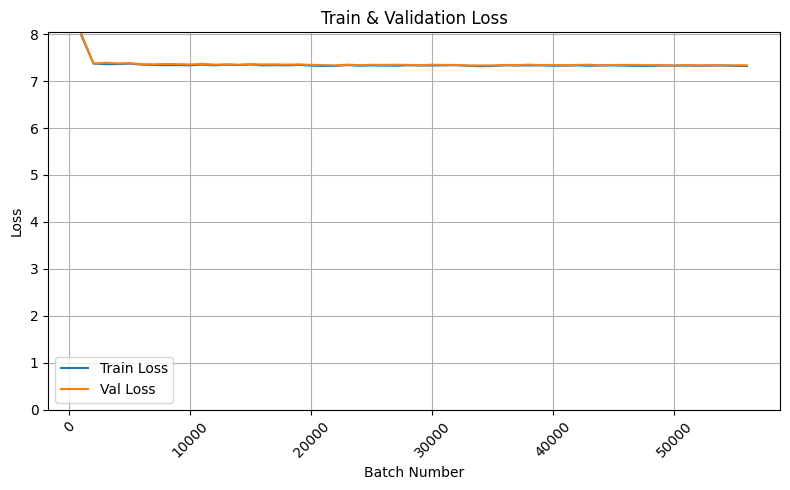

In [9]:
# ── Plot training and validation loss vs batch number ───────────────────────────────────────────────
import matplotlib.pyplot as plt
logger.info("Generating plot: training and validation loss vs batch number.")
plt.figure(figsize=(8,5))
plt.plot(batch_nums, train_losses, label="Train Loss")
plt.plot(batch_nums, val_losses,   label="Val Loss")
plt.xlabel("Batch Number")
plt.ylim(0)
plt.ylabel("Loss")
plt.title("Train & Validation Loss")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# generate from the model
input_tokens = tokenizer.encode("I like apple juice - I drink it")
input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=100)

print(tokenizer.decode(output[0].tolist()))